# Problem Set 1b: BHARs and calendar-time portfolios after stock splits

**How to run.** Put the seven CSV files in `DATA_DIR` (set in the first code cell; default `C:\Users\joaoac2\Downloads\PS1b\data`) and run all cells. Tables (`.tex` + `.csv`) and figures (`.png`) are written to `OUT_DIR` (default: `output` next to `data`). Every `[CHECK]` line is a sanity check; the full list is saved in `sanity_checks.csv`.

**Sections:** setup and data checks -> Q1 event panel -> Q2 BHAR -> Q3 size-decile benchmark (+ Q4 skewness-adjusted t) -> Q5 calendar-time portfolio -> Q6 factor regressions -> Q8 weighting -> robustness -> Q6/Q7 supporting tables -> save checks.

In [1]:
import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
from scipy import stats
try:                                           # inside Jupyter: show tables/figures inline
    from IPython.display import display
    IN_NOTEBOOK = "IPKernelApp" in get_ipython().config      # noqa: F821
except Exception:
    display, IN_NOTEBOOK = None, False

## Paths (override with environment variables if needed)

In [2]:
DATA_DIR = Path(os.environ.get("PS1B_DATA_DIR", r"C:\Users\joaoac2\Downloads\PS1b\data"))
OUT_DIR = Path(os.environ.get("PS1B_OUT_DIR", str(DATA_DIR.parent / "output")))
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_END_MI = 2025 * 12 + 11          # December 2025 as integer month index (year*12 + month-1)
NW_LAGS = 6                           # Newey-West lags (monthly data, 12-month overlapping holdings)
CHECKS = []                           # sanity checks collected for the appendix


def mi_to_str(mi):
    return f"{mi // 12}-{mi % 12 + 1:02d}"


def check(name, value, note=""):
    """Print and store a sanity check."""
    CHECKS.append({"check": name, "value": value, "note": note})
    print(f"[CHECK] {name}: {value}  {note}")


# ---- chart style: validated 3-colour categorical palette (blue, orange, aqua), diverging pair blue/red, ink tokens ----
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "red": "#e34948", "ink": "#0b0b0b", "ink2": "#52514e",
     "grid": "#e4e3df", "surface": "#fcfcfb", "band": "#efeeea"}
plt.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"], "savefig.facecolor": C["surface"],
    "axes.edgecolor": C["ink2"], "axes.labelcolor": C["ink2"], "xtick.color": C["ink2"], "ytick.color": C["ink2"],
    "text.color": C["ink"], "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.8,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": C["grid"], "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9, "font.size": 9.5,
    "lines.linewidth": 2, "figure.dpi": 110,
})
pct = FuncFormatter(lambda v, _: f"{v:+.0f}%".replace("+0%", "0%").replace("-", "\u2212"))
pct1 = FuncFormatter(lambda v, _: f"{v:.1f}%".replace("-", "\u2212"))


def finish_fig(fig, name):
    """Save a 300-dpi PNG; show inline in a notebook, otherwise close."""
    fig.savefig(OUT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


def fmt_df(df, nd=2):
    """Format float cells with nd decimals (strings and ints are left alone)."""
    return df.apply(lambda col: [f"{v:.{nd}f}" if isinstance(v, (float, np.floating)) else v for v in col])


def sig_stars(t):
    """Stars from a (Newey-West) t-statistic: * 10%, ** 5%, *** 1% (two-sided, normal)."""
    t = abs(t)
    return "***" if t > 2.576 else "**" if t > 1.960 else "*" if t > 1.645 else ""


# ---- LaTeX table writer: booktabs, grouped headers, shaded/bold key rows, superscript stars ----
def _esc(x):
    x = str(x)
    for a, b in [("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"), ("_", r"\_"),
                 ("{", r"\{"), ("}", r"\}"), ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")]:
        x = x.replace(a, b)
    x = re.sub(r"(?<![\w.])-(?=\d)", "$-$", x)                       # proper minus sign
    return re.sub(r"(\*{1,3})\s*$", r"\\textsuperscript{\1}", x)       # trailing stars as superscripts


def _fmt(v):
    return f"{v:.3f}" if isinstance(v, (float, np.floating)) else str(v)


def save_table(df, name, caption, label, index=True, colfmt=None, groups=None, bold_rows=(), shade_rows=(),
               rule_before=(), space_before=(), note=None, hide_label_re=None, index_header=""):
    """Save a CSV and a booktabs LaTeX table.
    groups: [(title, n_columns), ...] grouped header over the data columns; bold_rows / shade_rows / rule_before /
    space_before: row labels to style; hide_label_re: row labels matching the regex are printed blank (t-stat rows)."""
    df.to_csv(OUT_DIR / f"{name}.csv", index=index)
    ncol = len(df.columns) + (1 if index else 0)
    colfmt = colfmt or ("l" if index else "") + "r" * len(df.columns)
    L = [r"\begin{table}[!htbp]", r"\centering", r"\small", rf"\caption{{{caption}}}", rf"\label{{{label}}}",
         rf"\begin{{tabular}}{{{colfmt}}}", r"\toprule"]
    if groups:
        cells, rules, pos = [""] if index else [], [], 2 if index else 1
        for title, span in groups:
            cells.append(rf"\multicolumn{{{span}}}{{c}}{{{_esc(title)}}}")
            rules.append(rf"\cmidrule(lr){{{pos}-{pos + span - 1}}}")
            pos += span
        L += [" & ".join(cells) + r" \\", "".join(rules)]
    L += [" & ".join(([_esc(index_header)] if index else []) + [_esc(c) for c in df.columns]) + r" \\", r"\midrule"]
    for lab, row in zip(df.index, df.itertuples(index=False)):
        if lab in rule_before:
            L.append(r"\midrule")
        elif lab in space_before:
            L.append(r"\addlinespace")
        shown = "" if (hide_label_re and re.search(hide_label_re, str(lab))) else _esc(lab)
        cells = [shown] if index else []
        cells += [_esc(_fmt(v)) for v in row]
        if lab in bold_rows:
            cells = [rf"\textbf{{{c}}}" if c else c for c in cells]
        prefix = r"\rowcolor[gray]{0.94} " if lab in shade_rows else ""
        L.append(prefix + " & ".join(cells) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}"]
    if note:
        L += [r"\par\vspace{3pt}", rf"{{\footnotesize {note}}}"]
    L.append(r"\end{table}")
    (OUT_DIR / f"{name}.tex").write_text("\n".join(L) + "\n")
    print(f"\n=== {name} ===")
    display(df) if display is not None and IN_NOTEBOOK else print(df.to_string())

## French data parsers

In [3]:
def read_french_block(path, block=0):
    """Return the `block`-th contiguous block of 'yyyymm, v1, v2...' rows with its header line."""
    lines = Path(path).read_text(encoding="latin-1").splitlines()
    pat = re.compile(r"^\s*\d{6}\s*,")
    blocks, cur, start = [], [], None
    for i, ln in enumerate(lines):
        if pat.match(ln):
            if not cur:
                start = i
            cur.append(ln)
        elif cur:
            blocks.append((start, cur))
            cur = []
    if cur:
        blocks.append((start, cur))
    start, rows = blocks[block]
    header = lines[start - 1]
    return header, rows


def parse_french(path, block=0, header=None):
    hdr, rows = read_french_block(path, block)
    cols = header if header is not None else [c.strip() for c in hdr.split(",")][1:]
    recs = []
    for r in rows:
        parts = [p.strip() for p in r.split(",") if p.strip() != ""]
        recs.append(parts)
    df = pd.DataFrame(recs)
    df = df.apply(pd.to_numeric)
    ym = df.iloc[:, 0].astype(int)
    df = df.iloc[:, 1:]
    df.columns = cols[: df.shape[1]]
    df.index = (ym // 100) * 12 + (ym % 100) - 1       # month index
    df.index.name = "mi"
    df = df.replace([-99.99, -999, -999.0], np.nan)
    return df

## 0. Load data

In [4]:
daily = pd.read_csv(DATA_DIR / "stock_daily.csv", parse_dates=["date"])
splits = pd.read_csv(DATA_DIR / "stock_splits.csv", parse_dates=["disdeclaredt", "disexdt"])

check("daily rows", len(daily), "(manifest: 629,274)")
check("split events", len(splits), "(manifest: 232)")
check("daily duplicates (permno,date)", int(daily.duplicated(["permno", "date"]).sum()))
check("daily missing ret / mkt_ret / mktcap", f"{int(daily.ret.isna().sum())} / {int(daily.mkt_ret.isna().sum())} / {int(daily.mktcap.isna().sum())}")
check("distinct permnos in daily", daily.permno.nunique())
check("event permnos missing from daily", int((~splits.permno.isin(daily.permno)).sum()))
check("duplicated event_id", int(splits.event_id.duplicated().sum()))
check("ex-date range", f"{splits.disexdt.min().date()} to {splits.disexdt.max().date()}")
check("ex-date before declaration date", int((splits.disexdt < splits.disdeclaredt).sum()))
check("daily ret min / max", f"{daily.ret.min():.3f} / {daily.ret.max():.3f}", "decimal returns; max is a real +1140% (penny-stock) day, kept")
mk_per_date = daily.groupby("date").mkt_ret.nunique()
check("dates with >1 distinct mkt_ret", int((mk_per_date > 1).sum()), "mkt_ret is one series")

daily = daily.sort_values(["permno", "date"]).reset_index(drop=True)
cal = np.sort(daily.date.unique())                       # market trading calendar
cal_idx = pd.Series(np.arange(len(cal)), index=pd.DatetimeIndex(cal))
mkt_daily = daily.groupby("date").mkt_ret.first()
check("trading days in calendar", len(cal), "(approx. 252 x 14 = 3,528)")

[CHECK] daily rows: 629274  (manifest: 629,274)
[CHECK] split events: 232  (manifest: 232)
[CHECK] daily duplicates (permno,date): 0  
[CHECK] daily missing ret / mkt_ret / mktcap: 0 / 0 / 0  
[CHECK] distinct permnos in daily: 202  
[CHECK] event permnos missing from daily: 0  
[CHECK] duplicated event_id: 0  
[CHECK] ex-date range: 2014-01-08 to 2025-12-23  
[CHECK] ex-date before declaration date: 0  
[CHECK] daily ret min / max: -0.890 / 11.400  decimal returns; max is a real +1140% (penny-stock) day, kept
[CHECK] dates with >1 distinct mkt_ret: 0  mkt_ret is one series


[CHECK] trading days in calendar: 3520  (approx. 252 x 14 = 3,528)


## 1. Fill empty returns inside a stock's history with the market return

In [5]:
daily["ci"] = daily.date.map(cal_idx)
daily["mi"] = daily.date.dt.year * 12 + daily.date.dt.month - 1
span = daily.groupby("permno").ci.agg(["min", "max"])
grid = pd.concat([pd.DataFrame({"permno": p, "ci": np.arange(lo, hi + 1)}) for p, (lo, hi) in span.iterrows()],
                 ignore_index=True)
grid = grid.merge(daily[["permno", "ci", "ret", "mktcap"]], on=["permno", "ci"], how="left")
grid["date"] = pd.DatetimeIndex(cal)[grid.ci]
grid["mi"] = grid.date.dt.year * 12 + grid.date.dt.month - 1
grid["mkt_ret"] = grid.date.map(mkt_daily)
grid["actual"] = grid.ret.notna()
# a month with NO actual observation is a "stops trading" month (handled in the event panel),
# so empty days are filled only in months where the stock has at least one real return
n_act = grid.groupby(["permno", "mi"]).actual.transform("sum")
n_grid_total = len(grid)
grid = grid[n_act > 0].copy()
n_dropped_empty_months = n_grid_total - len(grid)
to_fill = grid.ret.isna()
check("explicit NaN ret in raw file", int(daily.ret.isna().sum()))
check("empty stock-days inside stock history filled with mkt_ret", int(to_fill.sum()),
      f"({to_fill.mean():.4%} of {len(grid):,} stock-days)")
check("stock-days in wholly-empty months (not filled, month treated as 'stopped trading')", n_dropped_empty_months)
grid.loc[to_fill, "ret"] = grid.loc[to_fill, "mkt_ret"]
check("remaining NaN returns after fill", int(grid.ret.isna().sum()))
check("filled-days by permno (top 5)", grid[to_fill].groupby("permno").size().sort_values(ascending=False).head(5).to_dict())

[CHECK] explicit NaN ret in raw file: 0  
[CHECK] empty stock-days inside stock history filled with mkt_ret: 91  (0.0145% of 629,365 stock-days)
[CHECK] stock-days in wholly-empty months (not filled, month treated as 'stopped trading'): 923  
[CHECK] remaining NaN returns after fill: 0  
[CHECK] filled-days by permno (top 5): {15664: 23, 92043: 23, 90400: 22, 91907: 16, 13554: 4}  


## 2. Monthly returns (compounded daily), monthly market return, end-of-month cap

In [6]:
grid["lr"] = np.log1p(grid.ret)
mon = grid.groupby(["permno", "mi"]).agg(ret=("lr", lambda x: np.expm1(x.sum())), ndays=("lr", "size")).reset_index()
last_cap = (grid[grid.actual].sort_values("date").groupby(["permno", "mi"]).mktcap.last()
            .rename("mktcap_end").reset_index())
mon = mon.merge(last_cap, on=["permno", "mi"], how="left")
mon_stock = mon.set_index(["permno", "mi"]).sort_index()
check("monthly stock-months", len(mon_stock))
check("monthly stock-return range", f"{mon_stock.ret.min():.3f} to {mon_stock.ret.max():.3f}")

mk = pd.DataFrame({"mkt_ret": mkt_daily})
mk["mi"] = mk.index.year * 12 + mk.index.month - 1
mon_mkt = mk.groupby("mi").mkt_ret.agg(lambda x: np.expm1(np.log1p(x).sum()))
ndays_mkt = mk.groupby("mi").size()
check("market days per month: min / max", f"{ndays_mkt.min()} / {ndays_mkt.max()}", "(expect ~19-23)")
check("monthly market return mean / sd (decimal)", f"{mon_mkt.mean():.4f} / {mon_mkt.std():.4f}")

[CHECK] monthly stock-months: 30067  
[CHECK] monthly stock-return range: -0.824 to 16.251  
[CHECK] market days per month: min / max: 19 / 23  (expect ~19-23)
[CHECK] monthly market return mean / sd (decimal): 0.0113 / 0.0408  


## 3. French data

In [7]:
ff3 = parse_french(DATA_DIR / "F-F_Research_Data_Factors.csv", 0) / 100
ff5 = parse_french(DATA_DIR / "F-F_Research_Data_5_Factors_2x3.csv", 0) / 100
mom = parse_french(DATA_DIR / "F-F_Momentum_Factor.csv", 0) / 100
mom.columns = [c.strip() for c in mom.columns]
dec_names = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec", "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
hdr_me, _ = read_french_block(DATA_DIR / "Portfolios_Formed_on_ME.csv", 0)
assert "Hi 10" in hdr_me, "first block of Portfolios_Formed_on_ME is not the value-weighted block"
me_vw = parse_french(DATA_DIR / "Portfolios_Formed_on_ME.csv", 0)[dec_names] / 100
bp_raw = parse_french(DATA_DIR / "ME_Breakpoints.csv", 0,
                      header=["n_nyse"] + [f"p{5 * k}" for k in range(1, 21)])
check("French monthly ranges (ff3 / ff5 / mom / ME-VW / ME bp)",
      f"{mi_to_str(ff3.index.min())}-{mi_to_str(ff3.index.max())} / {mi_to_str(ff5.index.min())}-{mi_to_str(ff5.index.max())} / "
      f"{mi_to_str(mom.index.min())}-{mi_to_str(mom.index.max())} / {mi_to_str(me_vw.index.min())}-{mi_to_str(me_vw.index.max())} / "
      f"{mi_to_str(bp_raw.index.min())}-{mi_to_str(bp_raw.index.max())}")
check("ff3 Mkt-RF mean / sd in 2014-2025 (decimal/month)",
      f"{ff3.loc[2014*12:2025*12+11, 'Mkt-RF'].mean():.4f} / {ff3.loc[2014*12:2025*12+11, 'Mkt-RF'].std():.4f}",
      "(units: percent/100)")
check("ME breakpoints monotone in p5..p100", bool((bp_raw.filter(like="p").diff(axis=1).iloc[:, 1:] > 0).all().all()))
check("ME-VW decile NaNs", int(me_vw.isna().sum().sum()))
common = ff3.index.intersection(ff5.index)
check("Mkt-RF ff3 vs ff5 max abs diff", float((ff3.loc[common, "Mkt-RF"] - ff5.loc[common, "Mkt-RF"]).abs().max()), "(<=0.08pp: file-vintage/rounding differences, immaterial)")
check("SMB ff3 vs ff5 max abs diff", float((ff3.loc[common, "SMB"] - ff5.loc[common, "SMB"]).abs().max()), "(SMB differs: 3-factor file sorts on size/B-M, 5-factor file averages SMB over B/M, OP and Inv sorts)")

# Cross-check: monthly compounded mkt_ret vs French CRSP value-weighted market (Mkt-RF + RF)
frm = (ff3["Mkt-RF"] + ff3["RF"])
j = pd.concat([mon_mkt.rename("mine"), frm.rename("french")], axis=1, join="inner")
check("corr(compounded mkt_ret, French Mkt-RF+RF) monthly", f"{j.mine.corr(j.french):.5f}", f"over {len(j)} months")
check("max abs diff (compounded mkt_ret - French Mkt)", f"{(j.mine - j.french).abs().max():.4f}")
check("mean monthly diff (mkt_ret - French Mkt), and 2014-2025 compounded return of each",
      f"{(j.mine - j.french).mean():.5f}; {np.expm1(np.log1p(j.mine[j.index >= 2014 * 12]).sum()):.3f} vs {np.expm1(np.log1p(j.french[j.index >= 2014 * 12]).sum()):.3f}",
      "mkt_ret runs ~0.11pp/month (~1.4%/yr) BELOW French's market: BHAR benchmark is slightly easier than the factor-model market")

[CHECK] French monthly ranges (ff3 / ff5 / mom / ME-VW / ME bp): 1926-07-2026-08 / 1963-07-2026-08 / 1927-01-2026-08 / 1926-07-2026-08 / 1925-12-2026-08  
[CHECK] ff3 Mkt-RF mean / sd in 2014-2025 (decimal/month): 0.0099 / 0.0435  (units: percent/100)
[CHECK] ME breakpoints monotone in p5..p100: True  
[CHECK] ME-VW decile NaNs: 0  
[CHECK] Mkt-RF ff3 vs ff5 max abs diff: 0.000800000000000009  (<=0.08pp: file-vintage/rounding differences, immaterial)
[CHECK] SMB ff3 vs ff5 max abs diff: 0.0351  (SMB differs: 3-factor file sorts on size/B-M, 5-factor file averages SMB over B/M, OP and Inv sorts)
[CHECK] corr(compounded mkt_ret, French Mkt-RF+RF) monthly: 0.99772  over 168 months
[CHECK] max abs diff (compounded mkt_ret - French Mkt): 0.0092  
[CHECK] mean monthly diff (mkt_ret - French Mkt), and 2014-2025 compounded return of each: -0.00115; 2.825 vs 3.420  mkt_ret runs ~0.11pp/month (~1.4%/yr) BELOW French's market: BHAR benchmark is slightly easier than the factor-model market


## Q1. Event-time panel

In [8]:
ev = splits.copy()
ev["m0"] = ev.disexdt.dt.year * 12 + ev.disexdt.dt.month - 1
ev["m0_has_obs"] = [(p, m) in mon_stock.index for p, m in zip(ev.permno, ev.m0)]
check("events with trading obs in month 0", f"{ev.m0_has_obs.sum()} of {len(ev)}")

pan = ev[["event_id", "permno", "m0"]].merge(pd.DataFrame({"tau": np.arange(1, 13)}), how="cross")
pan["mi"] = pan.m0 + pan.tau
pan = pan[pan.mi <= DATA_END_MI].copy()                          # data end cuts the window
pan = pan.merge(mon_stock[["ret", "mktcap_end"]].reset_index().rename(columns={"ret": "ret_stock"}),
                on=["permno", "mi"], how="left")
pan["ret_mkt"] = pan.mi.map(mon_mkt)
pan["has_obs"] = pan.ret_stock.notna()
stop_tau = pan[~pan.has_obs].groupby("event_id").tau.min().rename("stop_tau")
pan = pan.merge(stop_tau, on="event_id", how="left")
pan["held"] = pan.stop_tau.isna() | (pan.tau < pan.stop_tau)       # still holding the stock
pan["ret_used"] = np.where(pan.held, pan.ret_stock, pan.ret_mkt)    # proceeds go to mkt_ret after the stop
pan = pan.sort_values(["event_id", "tau"]).reset_index(drop=True)
check("panel rows with NaN ret_used", int(pan.ret_used.isna().sum()))
check("panel rows with NaN ret_mkt", int(pan.ret_mkt.isna().sum()))
check("monthly stock return inside event windows: min / max", f"{pan.ret_stock.min():.3f} / {pan.ret_stock.max():.3f}",
      "the four >+200% single-day spikes in the file (micro-caps, real cap jumps) fall outside all event windows")

ev["n_months"] = ev.event_id.map(pan.groupby("event_id").size()).fillna(0).astype(int)
ev["cut_data_end"] = ev.m0 + 12 > DATA_END_MI
ev["cut_stop"] = ev.event_id.isin(stop_tau.index)
ev["stop_tau"] = ev.event_id.map(stop_tau)
ev["full12"] = ev.n_months == 12
ev["bhar_ok"] = ~ev.cut_data_end                                  # month +12 on or before Dec 2025
q1 = pd.Series({
    "Split events (stock_splits.csv)": len(ev),
    "Events with at least one window month <= Dec 2025": int((ev.n_months > 0).sum()),
    "Events whose ex-date month is Dec 2025 (no window month at all)": int((ev.n_months == 0).sum()),
    "Panel rows (event x month)": len(pan),
    "Cut short by data end (month +12 after Dec 2025)": int(ev.cut_data_end.sum()),
    "Cut short by stock stopping trading (in window, <= Dec 2025)": int(ev.cut_stop.sum()),
    "   of which also cut by data end": int((ev.cut_stop & ev.cut_data_end).sum()),
    "   stopped trading only (full 12 months, proceeds in market)": int((ev.cut_stop & ~ev.cut_data_end).sum()),
    "   stock has no data from month +1 (all 12 months = market)": int((ev.stop_tau == 1).sum()),
    "Complete events (12 months, never stops)": int((~ev.cut_data_end & ~ev.cut_stop).sum()),
    "Events with 12-month BHAR (month +12 <= Dec 2025)": int(ev.bhar_ok.sum()),
}).to_frame("Events")
save_table(q1, "table1_event_panel",
           "Q1: Event-time panel. Window = calendar months +1 to +12 after the ex-date month (month 0). "
           "'Cut short by data end' = month +12 falls after Dec 2025; 'cut short by stock stopping trading' = a window month "
           "up to Dec 2025 has no daily returns for the stock (proceeds are invested in mkt\\_ret for the rest of the window). "
           "The two reasons overlap for some events, so rows do not add up to the total.", "tab:q1", colfmt="p{11cm}r",
           bold_rows=("Events with 12-month BHAR (month +12 <= Dec 2025)",), shade_rows=("Events with 12-month BHAR (month +12 <= Dec 2025)",),
           space_before=("Panel rows (event x month)", "Cut short by data end (month +12 after Dec 2025)", "Complete events (12 months, never stops)"))
check("events by ex-year", ev.disexdt.dt.year.value_counts().sort_index().to_dict())
check("panel rows by tau (each should be <= #events)", pan.groupby("tau").size().to_dict())
check("expected panel rows = sum(min(12, DATA_END - m0))", int(np.clip(DATA_END_MI - ev.m0, 0, 12).sum()), f"observed {len(pan)}")

# independent recomputation of monthly returns for a handful of events directly from daily data
rng = np.random.default_rng(0)
sample = ev[ev.full12 & ~ev.cut_stop].sample(8, random_state=1)
maxdiff = 0
for _, r in sample.iterrows():
    lo = pd.Timestamp(year=(r.m0 + 1) // 12, month=(r.m0 + 1) % 12 + 1, day=1)
    hi = pd.Timestamp(year=(r.m0 + 12) // 12, month=(r.m0 + 12) % 12 + 1, day=1) + pd.offsets.MonthEnd(0)
    g = grid[(grid.permno == r.permno) & (grid.date >= lo) & (grid.date <= hi)]
    direct = np.prod(1 + g.ret.values) - np.prod(1 + g.mkt_ret.values)
    p = pan[pan.event_id == r.event_id]
    viapanel = np.prod(1 + p.ret_used) - np.prod(1 + p.ret_mkt)
    maxdiff = max(maxdiff, abs(direct - viapanel))
check("BHAR from panel vs direct daily compounding (8 random events), max abs diff", f"{maxdiff:.2e}")

[CHECK] events with trading obs in month 0: 232 of 232  
[CHECK] panel rows with NaN ret_used: 0  
[CHECK] panel rows with NaN ret_mkt: 0  
[CHECK] monthly stock return inside event windows: min / max: -0.585 / 1.054  the four >+200% single-day spikes in the file (micro-caps, real cap jumps) fall outside all event windows

=== table1_event_panel ===


,Events
Split events (stock_splits.csv),232
Events with at least one window month <= Dec 2025,230
Events whose ex-date month is Dec 2025 (no window month at all),2
Panel rows (event x month),2681
Cut short by data end (month +12 after Dec 2025),19
"Cut short by stock stopping trading (in window, <= Dec 2025)",4
of which also cut by data end,0
"stopped trading only (full 12 months, proceeds in market)",4
stock has no data from month +1 (all 12 months = market),0
"Complete events (12 months, never stops)",209


[CHECK] events by ex-year: {2014: 41, 2015: 29, 2016: 17, 2017: 18, 2018: 13, 2019: 8, 2020: 9, 2021: 22, 2022: 20, 2023: 10, 2024: 26, 2025: 19}  
[CHECK] panel rows by tau (each should be <= #events): {1: 230, 2: 229, 3: 229, 4: 227, 5: 227, 6: 226, 7: 223, 8: 220, 9: 220, 10: 219, 11: 218, 12: 213}  
[CHECK] expected panel rows = sum(min(12, DATA_END - m0)): 2681  observed 2681


[CHECK] BHAR from panel vs direct daily compounding (8 random events), max abs diff: 2.66e-15  


## Q2. BHAR vs market

In [9]:
full = pan[pan.event_id.isin(ev[ev.bhar_ok].event_id)]
assert full.groupby("event_id").size().eq(12).all()
bhar = full.groupby("event_id").apply(lambda g: np.prod(1 + g.ret_used) - np.prod(1 + g.ret_mkt),
                                      include_groups=False).rename("bhar_mkt")
ev = ev.merge(bhar, left_on="event_id", right_index=True, how="left")
x = ev.bhar_mkt.dropna()


def bhar_stats(x):
    n = len(x)
    m, s = x.mean(), x.std(ddof=1)
    se = s / np.sqrt(n)
    g = ((x - m) ** 3).sum() / (n * s ** 3)
    S = m / s
    tsa = np.sqrt(n) * (S + g * S ** 2 / 3 + g / (6 * n))
    tcrit = stats.t.ppf(0.975, n - 1)
    return {
        "N events": n, "Mean": m, "Median": x.median(), "Std. dev.": s, "Std. error of mean": se,
        "t-statistic": m / se, "p-value (two-sided, t)": 2 * stats.t.sf(abs(m / se), n - 1),
        "Skewness (gamma-hat)": g, "p10": x.quantile(0.10), "p25": x.quantile(0.25),
        "p75": x.quantile(0.75), "p90": x.quantile(0.90), "Min": x.min(), "Max": x.max(),
        "Share of BHAR > 0": (x > 0).mean(),
        "t_SA (skewness-adjusted)": tsa,
        "Min. mean BHAR significant at 5%": tcrit * se,
        "Mean BHAR detectable with 80% power": (tcrit + stats.t.ppf(0.80, n - 1)) * se,
    }


st_mkt = bhar_stats(x)
stopped = ev[ev.cut_stop].copy()
last_dt = daily.groupby("permno").date.max()
stopped["last trading date in file"] = stopped.permno.map(last_dt).dt.date
stopped["Ex-date"] = stopped.disexdt.dt.date
stopped["First missing window month (tau)"] = stopped.stop_tau.astype(int)
save_table(stopped.set_index("event_id")[["permno", "Ex-date", "First missing window month (tau)", "last trading date in file"]]
           .rename(columns={"First missing window month (tau)": "First missing tau", "last trading date in file": "Last date in file"}),
           "table1b_stopped_events", "Q1 (check): the events whose window is cut short because the stock stops trading. For these events the "
           "proceeds go into mkt\\_ret from the first missing month (tau) to month +12. Permno 90400 has a long gap in its history "
           "(it trades again later, which the rule ignores).", "tab:q1b", colfmt="lrrrr")
fills = grid[to_fill][["permno", "mi"]].drop_duplicates()
n_ev_fill = int(sum(((fills.permno == p) & (fills.mi > m0) & (fills.mi <= m0 + 12)).any() for p, m0 in zip(ev.permno, ev.m0)))
check("events whose window contains a day filled with mkt_ret", n_ev_fill, "(only these events can be affected by the fill rule)")
# BHAR against French's market (Mkt-RF + RF) as a robustness check on the benchmark
pan["ret_frmkt"] = pan.mi.map(ff3["Mkt-RF"] + ff3["RF"])
fullb = pan[pan.event_id.isin(ev[ev.bhar_ok].event_id)]
bhar_fr = fullb.groupby("event_id").apply(lambda g: np.prod(1 + g.ret_used) - np.prod(1 + g.ret_frmkt), include_groups=False)
st_fr = bhar_stats(bhar_fr.dropna())
check("robustness: mean BHAR vs French market / t", f"{st_fr['Mean']:.4f} / {st_fr['t-statistic']:.2f}",
      "(provided mkt_ret is ~1.4%/yr lower than French's market)")
# clustering check: events in the same ex-date month share market shocks
cl = ev.dropna(subset=["bhar_mkt"]).assign(ym=lambda d: d.disexdt.dt.to_period("M"))
dev = cl.bhar_mkt - x.mean()
G = cl.ym.nunique()
se_cl = np.sqrt((dev.groupby(cl.ym).sum() ** 2).sum()) / len(cl) * np.sqrt(G / (G - 1))
check("SE of mean BHAR: iid vs clustered by ex-date month", f"{st_mkt['Std. error of mean']:.4f} vs {se_cl:.4f}", f"{G} clusters")
check("skewness gamma-hat vs scipy skew(bias=True)", f"{st_mkt['Skewness (gamma-hat)']:.3f} vs {stats.skew(x):.3f}")
check("events with stop at tau=1 (whole window = market, BHAR = 0)", int((ev.stop_tau == 1).sum()))
check("BHAR min / max", f"{x.min():.3f} / {x.max():.3f}", "BHAR >= -(1 + market return): sanity ok if min > -1.5")


=== table1b_stopped_events ===


,permno,Ex-date,First missing tau,Last date in file
event_id,,,,
14166_20240923_20241011,14166,2024-10-11,11,2025-08-01
80361_20140728_20140828,80361,2014-08-28,12,2015-07-01
83186_20170509_20170609,83186,2017-06-09,11,2018-04-16
90400_20140213_20140317,90400,2014-03-17,12,2025-12-31


[CHECK] events whose window contains a day filled with mkt_ret: 2  (only these events can be affected by the fill rule)
[CHECK] robustness: mean BHAR vs French market / t: -0.0062 / -0.26  (provided mkt_ret is ~1.4%/yr lower than French's market)
[CHECK] SE of mean BHAR: iid vs clustered by ex-date month: 0.0244 vs 0.0237  97 clusters
[CHECK] skewness gamma-hat vs scipy skew(bias=True): 0.408 vs 0.411  
[CHECK] events with stop at tau=1 (whole window = market, BHAR = 0): 0  
[CHECK] BHAR min / max: -0.927 / 1.366  BHAR >= -(1 + market return): sanity ok if min > -1.5


## Q3. BHAR vs NYSE size-decile benchmark

[CHECK] events with size decile assigned: 232 of 232  
[CHECK] cap at month 0: median / min / max ($ millions): 5,324 / 23.4 / 3,035,234  mktcap file unit is $ thousands; divided by 1,000 to match French's $ millions

=== table3_decile_dist ===


,Events,Share
NYSE size decile (1 = smallest),,
1,32,0.138
2,16,0.069
3,16,0.069
4,14,0.060
5,17,0.073
6,20,0.086
7,15,0.065
8,24,0.103
9,30,0.129


[CHECK] NaN decile benchmark returns in BHAR window: 0  


[CHECK] mean 12m benchmark return: market vs size-decile: 0.0978 vs 0.0745  
[CHECK] diff = BHAR_dec - BHAR_mkt equals bench_mkt - bench_dec (max abs err): 1.11e-16  

=== table2_bhar_summary ===


,vs. market,vs. size decile,Difference
N events,213,213,213
Mean (%),0.74,3.06,2.33
Median (%),1.53,3.35,1.03
p10 (%),-43.33,-36.44,-5.16
p25 (%),-21.59,-20.37,-3.00
p75 (%),18.58,20.36,7.11
p90 (%),44.08,48.31,12.17
Min (%),-92.69,-76.65,-11.59
Max (%),136.61,138.38,24.01
Share of BHAR > 0 (%),51.17,53.05,52.58


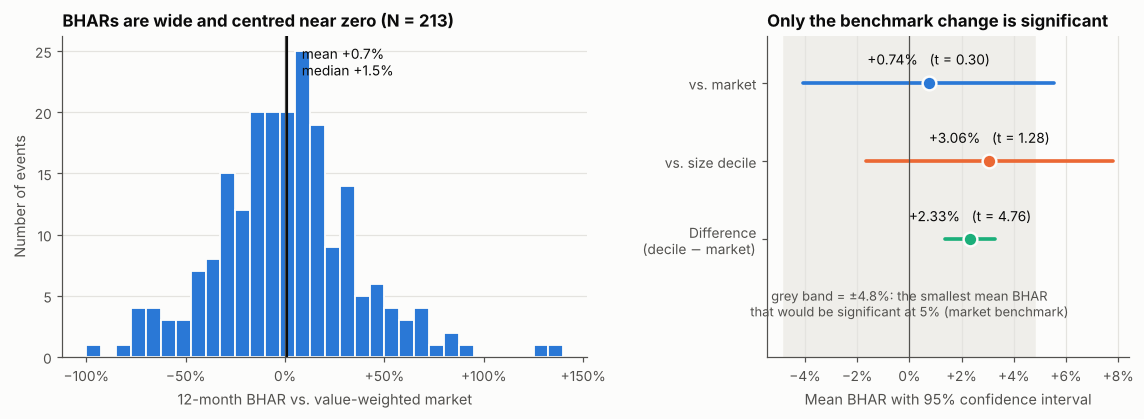

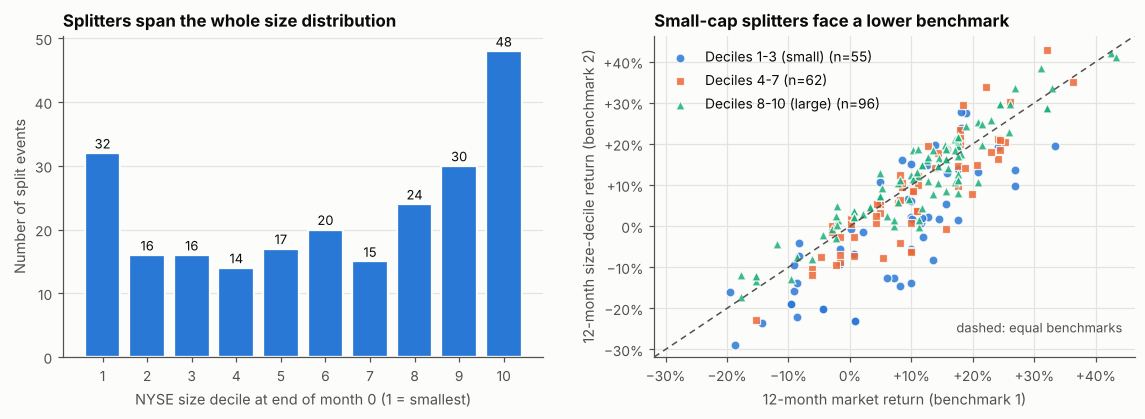

[CHECK] t-stat of paired difference (decile - market): 4.758  


In [10]:
cap0 = [mon_stock.mktcap_end.get((p, m), np.nan) for p, m in zip(ev.permno, ev.m0)]
ev["cap0_mil"] = np.array(cap0) / 1000.0                              # thousands of dollars -> millions
bp_dec = bp_raw[[f"p{10 * k}" for k in range(1, 10)]]                # 10th ... 90th NYSE percentiles
dec = []
for m, c in zip(ev.m0, ev.cap0_mil):
    if np.isnan(c) or m not in bp_dec.index:
        dec.append(np.nan)
    else:
        dec.append(int(np.searchsorted(bp_dec.loc[m].values, c, side="left")) + 1)
ev["decile"] = dec
check("events with size decile assigned", f"{ev.decile.notna().sum()} of {len(ev)}")
check("cap at month 0: median / min / max ($ millions)", f"{ev.cap0_mil.median():,.0f} / {ev.cap0_mil.min():,.1f} / {ev.cap0_mil.max():,.0f}",
      "mktcap file unit is $ thousands; divided by 1,000 to match French's $ millions")
dist = ev.decile.value_counts().sort_index().rename("Events").to_frame()
dist.index = [f"{int(i)}" for i in dist.index]
dist.index.name = "NYSE size decile (1 = smallest)"
dist["Share"] = dist.Events / dist.Events.sum()
save_table(dist.round(3), "table3_decile_dist",
           "Q3 (check): number of split events by NYSE size decile, assigned with market cap at the end of month 0 "
           "and French's NYSE ME breakpoints for that month (cap in $ thousands divided by 1,000 to match $ millions).", "tab:decile", colfmt="lrr")

dec_ret = me_vw.copy()
dec_ret.columns = range(1, 11)
pan["decile"] = pan.event_id.map(ev.set_index("event_id").decile)
pan["ret_dec"] = [dec_ret.at[m, int(d)] if (not np.isnan(d) and m in dec_ret.index) else np.nan
                  for m, d in zip(pan.mi, pan.decile)]
full = pan[pan.event_id.isin(ev[ev.bhar_ok].event_id)]
check("NaN decile benchmark returns in BHAR window", int(full.ret_dec.isna().sum()))
bhar_dec = full.groupby("event_id").apply(lambda g: np.prod(1 + g.ret_used) - np.prod(1 + g.ret_dec),
                                          include_groups=False).rename("bhar_dec")
bench_dec = full.groupby("event_id").apply(lambda g: np.prod(1 + g.ret_dec) - 1, include_groups=False).rename("bench_dec")
bench_mkt = full.groupby("event_id").apply(lambda g: np.prod(1 + g.ret_mkt) - 1, include_groups=False).rename("bench_mkt")
ev = ev.merge(bhar_dec, left_on="event_id", right_index=True, how="left") \
       .merge(bench_dec, left_on="event_id", right_index=True, how="left") \
       .merge(bench_mkt, left_on="event_id", right_index=True, how="left")
xd = ev.bhar_dec.dropna()
st_dec = bhar_stats(xd)
diff = (ev.bhar_dec - ev.bhar_mkt).dropna()        # = mkt benchmark return - decile benchmark return
st_diff = bhar_stats(diff)
check("mean 12m benchmark return: market vs size-decile", f"{ev.bench_mkt.mean():.4f} vs {ev.bench_dec.mean():.4f}")
check("diff = BHAR_dec - BHAR_mkt equals bench_mkt - bench_dec (max abs err)",
      f"{(diff + (ev.bench_dec - ev.bench_mkt).dropna()).abs().max():.2e}")

tab2 = pd.DataFrame({"vs. market": st_mkt, "vs. size decile": st_dec, "Difference": st_diff})
PCT_ROWS = ["Mean", "Median", "p10", "p25", "p75", "p90", "Min", "Max", "Std. dev.", "Std. error of mean", "Share of BHAR > 0",
            "Min. mean BHAR significant at 5%", "Mean BHAR detectable with 80% power"]
order = ["N events", "Mean", "Median", "p10", "p25", "p75", "p90", "Min", "Max", "Share of BHAR > 0", "Std. dev.", "Skewness (gamma-hat)",
         "Std. error of mean", "t-statistic", "p-value (two-sided, t)", "t_SA (skewness-adjusted)",
         "Min. mean BHAR significant at 5%", "Mean BHAR detectable with 80% power"]
tab2_print = pd.DataFrame({c: [f"{int(tab2.at[k, c])}" if k == "N events" else f"{tab2.at[k, c] * (100 if k in PCT_ROWS else 1):.2f}" for k in order]
                           for c in tab2.columns}, index=[k + (" (%)" if k in PCT_ROWS else "") for k in order])
save_table(tab2_print, "table2_bhar_summary",
           "Q2--Q4: 12-month buy-and-hold abnormal returns (BHAR = stock gross return minus benchmark gross return over months $+1$ to $+12$). "
           "Rows in percent are marked (\\%). 'vs.\\ market': benchmark is the compounded \\texttt{mkt\\_ret}; 'vs.\\ size decile': French's value-weighted return of the firm's "
           "NYSE size decile (month-0 cap); 'Difference': paired BHAR(decile) $-$ BHAR(market) over the same events, whose $t$-statistic tests whether the benchmark matters.",
           "tab:bhar", colfmt="lrrr", bold_rows=("Mean (%)", "t-statistic"), shade_rows=("Mean (%)", "t-statistic"),
           space_before=("Mean (%)", "Std. dev. (%)", "Std. error of mean (%)", "Min. mean BHAR significant at 5% (%)"),
           note="Standard error = sd$/\\sqrt{N}$. Skewness is $\\hat\\gamma$ of Q4; $t_{SA}$ is the Lyon-Barber-Tsai skewness-adjusted $t$. "
                "The last two rows give the smallest mean BHAR significant at 5\\% ($t_{N-1}$ critical value times s.e.) and the mean BHAR detectable with 80\\% power "
                "((critical $t$ + $t_{0.80}$) times s.e.).")
# ---- Figure 1: distribution and estimates (Q2-Q4) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9), gridspec_kw={"width_ratios": [1.45, 1]})
xs = x * 100
ax1.hist(xs, bins=np.arange(-100, 145, 7.5), color=C["blue"], edgecolor=C["surface"], linewidth=1.2)
ax1.axvline(0, color=C["ink2"], linewidth=0.8)
ymax = ax1.get_ylim()[1]
ax1.axvline(xs.mean(), color=C["ink"], linewidth=1.4)
ax1.annotate(f"mean {xs.mean():+.1f}%\nmedian {xs.median():+.1f}%", (xs.mean(), ymax * 0.97), xytext=(10, 0), textcoords="offset points", fontsize=9, va="top")
ax1.set_xlabel("12-month BHAR vs. value-weighted market"); ax1.set_ylabel("Number of events")
ax1.xaxis.set_major_formatter(pct)
ax1.set_title(f"BHARs are wide and centred near zero (N = {len(xs)})")
ax1.grid(axis="x", visible=False)
rows = [("vs. market", st_mkt, C["blue"]), ("vs. size decile", st_dec, C["orange"]), ("Difference\n(decile $-$ market)", st_diff, C["aqua"])]
for k, (lab, st_, col) in enumerate(rows):
    y = 2 - k
    tc = stats.t.ppf(0.975, st_["N events"] - 1)
    m_, se_ = st_["Mean"] * 100, st_["Std. error of mean"] * 100
    ax2.plot([m_ - tc * se_, m_ + tc * se_], [y, y], color=col, linewidth=2.4, solid_capstyle="round")
    ax2.plot(m_, y, "o", color=col, markersize=9, markeredgecolor=C["surface"], markeredgewidth=1.6)
    ax2.annotate(f"{m_:+.2f}%   (t = {st_['t-statistic']:.2f})".replace("-", "\u2212"), (m_, y), xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9)
mde = st_mkt["Min. mean BHAR significant at 5%"] * 100
ax2.axvspan(-mde, mde, color=C["band"], zorder=0)
ax2.annotate(f"grey band = \u00b1{mde:.1f}%: the smallest mean BHAR\nthat would be significant at 5% (market benchmark)", (0, -0.62), ha="center", va="top", fontsize=8.5, color=C["ink2"])
ax2.axvline(0, color=C["ink2"], linewidth=0.8)
ax2.set_yticks([2, 1, 0]); ax2.set_yticklabels([r[0] for r in rows]); ax2.set_ylim(-1.5, 2.6)
ax2.xaxis.set_major_formatter(pct); ax2.set_xlabel("Mean BHAR with 95% confidence interval")
ax2.set_title("Only the benchmark change is significant"); ax2.grid(axis="y", visible=False); ax2.grid(axis="x", visible=True)
fig.tight_layout(w_pad=2.5)
finish_fig(fig, "fig1_bhar")

# ---- Figure 3: where the splitters sit in the size distribution and what the benchmark does (Q3) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9), gridspec_kw={"width_ratios": [1, 1]})
cnt = ev.decile.value_counts().reindex(range(1, 11)).fillna(0)
ax1.bar(cnt.index, cnt.values, color=C["blue"], edgecolor=C["surface"], linewidth=1.5, width=0.8)
for d_, v_ in cnt.items():
    ax1.annotate(f"{int(v_)}", (d_, v_), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8.5)
ax1.set_xticks(range(1, 11)); ax1.set_xlabel("NYSE size decile at end of month 0 (1 = smallest)"); ax1.set_ylabel("Number of split events")
ax1.set_title("Splitters span the whole size distribution"); ax1.grid(axis="x", visible=False)
grp = pd.cut(ev.decile, [0, 3, 7, 10], labels=["Deciles 1-3 (small)", "Deciles 4-7", "Deciles 8-10 (large)"])
ok = ev.bench_mkt.notna()
for (g_, col), mk_ in zip(zip(grp.cat.categories, [C["blue"], C["orange"], C["aqua"]]), ["o", "s", "^"]):
    sel = ok & (grp == g_)
    ax2.scatter(ev.bench_mkt[sel] * 100, ev.bench_dec[sel] * 100, s=34, color=col, marker=mk_, alpha=0.85, edgecolor=C["surface"], linewidth=0.8,
                label=f"{g_} (n={int(sel.sum())})")
lim = [min(ev.bench_mkt.min(), ev.bench_dec.min()) * 100 - 3, max(ev.bench_mkt.max(), ev.bench_dec.max()) * 100 + 3]
ax2.plot(lim, lim, color=C["ink2"], linewidth=1, linestyle=(0, (4, 3)))
ax2.annotate("dashed: equal benchmarks", (lim[1] - 2, lim[0] + 6), ha="right", fontsize=8.5, color=C["ink2"])
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("12-month market return (benchmark 1)"); ax2.set_ylabel("12-month size-decile return (benchmark 2)")
ax2.xaxis.set_major_formatter(pct); ax2.yaxis.set_major_formatter(pct)
ax2.set_title("Small-cap splitters face a lower benchmark"); ax2.legend(loc="upper left"); ax2.grid(axis="x", visible=True)
fig.tight_layout(w_pad=2.5)
finish_fig(fig, "fig3_size_benchmark")
check("t-stat of paired difference (decile - market)", f"{st_diff['t-statistic']:.3f}")

## Q5. Calendar-time portfolio (equal-weighted, each stock once per month)

[CHECK] held event-months before / after removing overlapping splits of the same stock: 2675 / 2667  8 duplicates removed
[CHECK] held stock returns identical across duplicated events?: True  
[CHECK] calendar months in portfolio span / with >=1 stock: 143 / 143  
[CHECK] portfolio span: 2014-02 to 2025-12  
[CHECK] EW weights sum to 1 in every month (max abs deviation): 0.00e+00  

=== table5_portfolio ===


,Value
Calendar months in portfolio,143.0000
Average stocks held,18.6503
Minimum stocks held,4
Maximum stocks held,41
Months with fewer than 10 stocks,22.0000
Months with zero stocks,0.0000
Mean monthly portfolio return,0.0094
Std. dev. of monthly portfolio return,0.0562


[CHECK] months with n<10: first / last: 2014-02 / 2023-10  
[CHECK] portfolio monthly return range: -0.194 to 0.160  
[CHECK] max stocks held <= number of distinct event permnos: 41 <= 202  


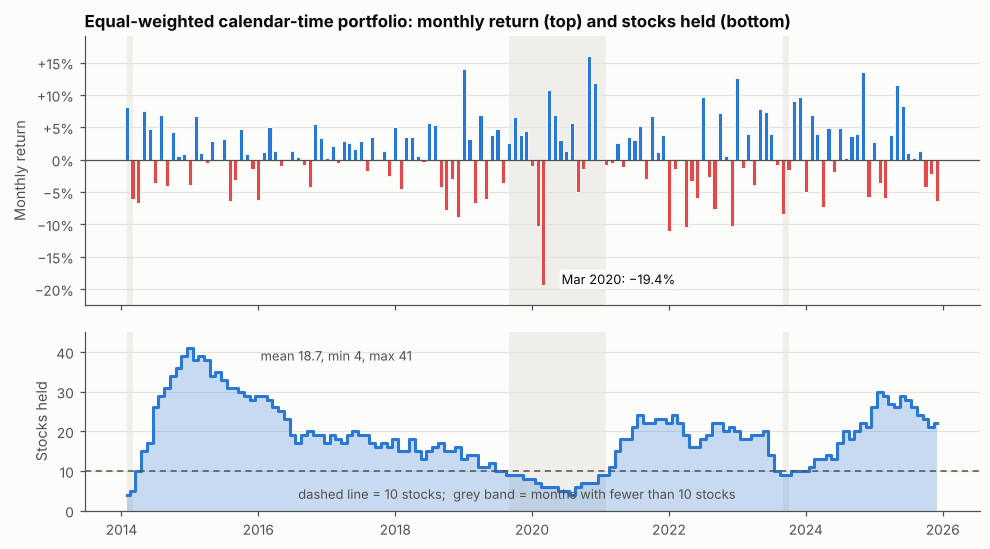

In [11]:
held = pan[pan.held][["event_id", "permno", "mi", "ret_stock"]].copy()
n_before = len(held)
held = held.drop_duplicates(["permno", "mi"])
check("held event-months before / after removing overlapping splits of the same stock", f"{n_before} / {len(held)}",
      f"{n_before - len(held)} duplicates removed")
check("held stock returns identical across duplicated events?",
      bool(pan[pan.held].groupby(["permno", "mi"]).ret_stock.nunique().max() == 1))
mon_p = held.groupby("mi").agg(rp=("ret_stock", "mean"), n=("permno", "size"))
months_all = np.arange(mon_p.index.min(), mon_p.index.max() + 1)
check("calendar months in portfolio span / with >=1 stock", f"{len(months_all)} / {len(mon_p)}")
check("portfolio span", f"{mi_to_str(mon_p.index.min())} to {mi_to_str(mon_p.index.max())}")
# weights sum to one
w_sum = held.groupby("mi").permno.transform(lambda s: 1 / len(s)).groupby(held.mi).sum()
check("EW weights sum to 1 in every month (max abs deviation)", f"{(w_sum - 1).abs().max():.2e}")
q5 = pd.Series({
    "Calendar months in portfolio": len(mon_p),
    "Average stocks held": mon_p.n.mean(),
    "Minimum stocks held": mon_p.n.min(),
    "Maximum stocks held": mon_p.n.max(),
    "Months with fewer than 10 stocks": int((mon_p.n < 10).sum()),
    "Months with zero stocks": len(months_all) - len(mon_p),
    "Mean monthly portfolio return": mon_p.rp.mean(),
    "Std. dev. of monthly portfolio return": mon_p.rp.std(),
}).to_frame("Value")
q5["Value"] = [f"{v:.0f}" if (isinstance(v, (int, np.integer)) or k in ("Minimum stocks held", "Maximum stocks held")) else f"{v:.4f}" for k, v in q5.Value.items()]
save_table(q5, "table5_portfolio", "Q5: equal-weighted calendar-time portfolio of stocks within months +1 to +12 of a split window "
           "(a stock with overlapping splits is held once; a stock is dropped after its last trading month).", "tab:q5", colfmt="p{9cm}r")
check("months with n<10: first / last", f"{mi_to_str(mon_p[mon_p.n < 10].index.min())} / {mi_to_str(mon_p[mon_p.n < 10].index.max())}"
      if (mon_p.n < 10).any() else "none")
check("portfolio monthly return range", f"{mon_p.rp.min():.3f} to {mon_p.rp.max():.3f}")
# the portfolio count must equal the count of unique permno-months implied by event windows
check("max stocks held <= number of distinct event permnos", f"{mon_p.n.max()} <= {ev.permno.nunique()}")

xm = pd.PeriodIndex([pd.Period(mi_to_str(m), "M") for m in mon_p.index]).to_timestamp()
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10.5, 5.6), gridspec_kw={"height_ratios": [1.5, 1], "hspace": 0.12})
thin = (mon_p.n < 10).values
for a_ in (ax1, ax2):                                    # shade months with fewer than 10 stocks (contiguous runs)
    a_.fill_between(xm, 0, 1, where=thin, step="mid", transform=a_.get_xaxis_transform(), color=C["band"], zorder=0, linewidth=0)
r_ = mon_p.rp.values * 100
ax1.bar(xm, r_, width=22, color=np.where(r_ >= 0, C["blue"], C["red"]), edgecolor=C["surface"], linewidth=0.6)
ax1.axhline(0, color=C["ink2"], linewidth=0.8)
ax1.yaxis.set_major_formatter(pct); ax1.set_ylabel("Monthly return")
ax1.set_title("Equal-weighted calendar-time portfolio: monthly return (top) and stocks held (bottom)")
for lab_, idx_ in [("Mar 2020", int(np.argmin(r_)))]:
    ax1.annotate(f"{lab_}: {r_[idx_]:.1f}%".replace("-", "\u2212"), (xm[idx_], r_[idx_]), xytext=(12, 4), textcoords="offset points", fontsize=8.5, va="center",
                 bbox=dict(boxstyle="round,pad=0.15", fc=C["surface"], ec="none"))
ax1.set_ylim(r_.min() - 3, r_.max() + 3)
ax1.grid(axis="x", visible=False)
ax2.fill_between(xm, mon_p.n.values, step="mid", color=C["blue"], alpha=0.25, linewidth=0)
ax2.step(xm, mon_p.n.values, where="mid", color=C["blue"], linewidth=2)
ax2.axhline(10, color=C["ink2"], linewidth=1, linestyle=(0, (4, 3)))
ax2.annotate("dashed line = 10 stocks;  grey band = months with fewer than 10 stocks", (xm[30], 2.2), fontsize=8.5, color=C["ink2"], va="bottom")
ax2.annotate(f"mean {mon_p.n.mean():.1f}, min {mon_p.n.min()}, max {mon_p.n.max()}", (xm[2], mon_p.n.max()), fontsize=8.5, color=C["ink2"], va="top", xytext=(80, 0), textcoords="offset points")
ax2.set_ylabel("Stocks held"); ax2.set_ylim(0, mon_p.n.max() * 1.1); ax2.grid(axis="x", visible=False)
finish_fig(fig, "fig2_portfolio")

## Q6. Factor regressions

[CHECK] months in portfolio missing French factors (3f / mom / 5f): 0 / 0 / 0  
[CHECK] RF mean (decimal/month) over sample: 0.00146  (about 1.75%/yr: near zero in 2014-2021, 4-5% in 2023-2025)
[CHECK] RF ff3 vs ff5 identical: True  

=== table6_factor_regressions ===


,(1) No factors,(2) CAPM,(3) FF3,(4) FF3+Mom,(5) FF5
alpha (% per month),0.796**,-0.325,-0.121,-0.124,-0.114
alpha t (NW),[2.27],[-1.52],[-0.51],[-0.53],[-0.48]
alpha t (OLS),(1.70),(-1.29),(-0.53),(-0.54),(-0.49)
Mkt-RF,,1.102***,1.003***,1.005***,0.988***
Mkt-RF t (NW),,[23.20],[26.66],[22.42],[24.37]
SMB,,,0.505***,0.507***,0.456***
SMB t (NW),,,[7.86],[7.93],[6.65]
HML,,,-0.091,-0.088,-0.114
HML t (NW),,,[-1.10],[-0.96],[-0.99]
Mom,,,,0.009,


[CHECK] model (1) alpha == mean excess return: 0.007960 vs 0.007960  
[CHECK] CAPM alpha/beta: statsmodels vs numpy lstsq (max abs diff): 2.22e-16  

=== table6b_nw_lags ===


,"NW t(alpha), 0 lags","NW t(alpha), 3 lags","NW t(alpha), 6 lags","NW t(alpha), 12 lags"
(2) CAPM,-1.34,-1.38,-1.52,-1.83
(3) FF3,-0.56,-0.52,-0.51,-0.56
(4) FF3+Mom,-0.56,-0.53,-0.53,-0.57


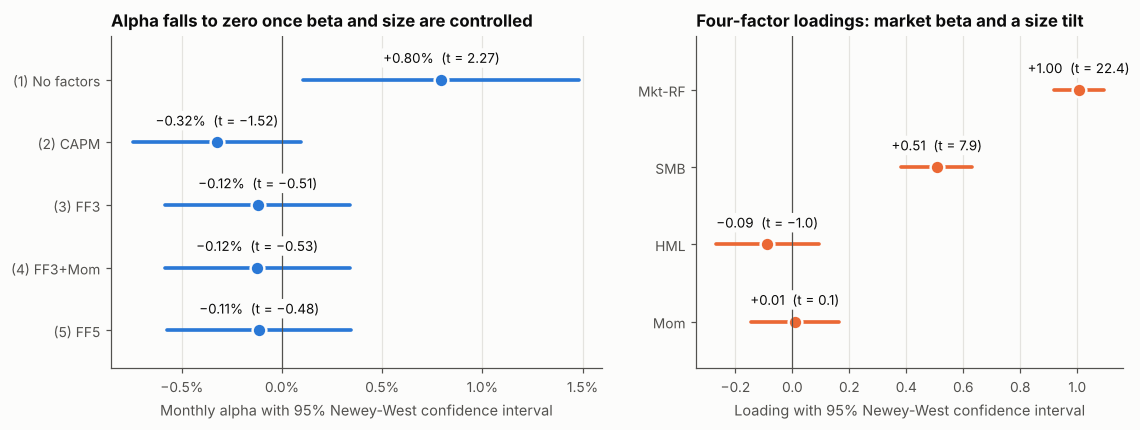

In [12]:
panel_m = mon_p.copy()
panel_m["rf"] = ff3.RF.reindex(panel_m.index)
for c in ["Mkt-RF", "SMB", "HML"]:
    panel_m[c] = ff3[c].reindex(panel_m.index)
panel_m["Mom"] = mom["Mom"].reindex(panel_m.index)
for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]:
    panel_m[c + "_5"] = ff5[c].reindex(panel_m.index)
panel_m["rf5"] = ff5.RF.reindex(panel_m.index)
panel_m["ex"] = panel_m.rp - panel_m.rf
check("months in portfolio missing French factors (3f / mom / 5f)",
      f"{int(panel_m['Mkt-RF'].isna().sum())} / {int(panel_m.Mom.isna().sum())} / {int(panel_m['Mkt-RF_5'].isna().sum())}")
check("RF mean (decimal/month) over sample", f"{panel_m.rf.mean():.5f}", "(about 1.75%/yr: near zero in 2014-2021, 4-5% in 2023-2025)")
check("RF ff3 vs ff5 identical", bool((panel_m.rf - panel_m.rf5).abs().max() < 1e-12))

MODELS = {
    "(1) No factors": [],
    "(2) CAPM": ["Mkt-RF"],
    "(3) FF3": ["Mkt-RF", "SMB", "HML"],
    "(4) FF3+Mom": ["Mkt-RF", "SMB", "HML", "Mom"],
    "(5) FF5": ["Mkt-RF_5", "SMB_5", "HML_5", "RMW_5", "CMA_5"],
}
LABEL = {"Mkt-RF_5": "Mkt-RF", "SMB_5": "SMB", "HML_5": "HML", "RMW_5": "RMW", "CMA_5": "CMA"}
ROWS = ["Mkt-RF", "SMB", "HML", "Mom", "RMW", "CMA"]


def fit(y, X, w=None, lags=NW_LAGS):
    Xc = sm.add_constant(X) if X is not None and X.shape[1] > 0 else pd.DataFrame({"const": np.ones(len(y))}, index=y.index)
    mod = sm.WLS(y, Xc, weights=w) if w is not None else sm.OLS(y, Xc)
    ols = mod.fit()
    nw = mod.fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return ols, nw


def reg_table(df, ycol, models, w=None, title=""):
    """Table with coefficient (stars from Newey-West t), [t NW], (t OLS) for alpha, N, R2 and alpha standard errors."""
    cols, res = {}, {}
    for name, fac in models.items():
        X = df[fac] if fac else None
        ols, nw = fit(df[ycol], X, w)
        res[name] = (ols, nw)
        c = {}
        c["alpha (% per month)"] = f"{ols.params['const'] * 100:.3f}{sig_stars(nw.tvalues['const'])}"
        c["alpha t (NW)"] = f"[{nw.tvalues['const']:.2f}]"
        c["alpha t (OLS)"] = f"({ols.tvalues['const']:.2f})"
        for r in ROWS:
            src = [f for f in fac if LABEL.get(f, f) == r]
            if src:
                f = src[0]
                c[r] = f"{ols.params[f]:.3f}{sig_stars(nw.tvalues[f])}"
                c[f"{r} t (NW)"] = f"[{nw.tvalues[f]:.2f}]"
            else:
                c[r] = ""
                c[f"{r} t (NW)"] = ""
        c["N months"] = f"{int(ols.nobs)}"
        c["R-squared"] = f"{ols.rsquared:.3f}"
        c["SE alpha, OLS (%)"] = f"{ols.bse['const'] * 100:.3f}"
        c["SE alpha, Newey-West (%)"] = f"{nw.bse['const'] * 100:.3f}"
        cols[name] = c
    t = pd.DataFrame(cols)
    keep = [i for i in t.index if not (t.loc[i] == "").all()]
    return t.loc[keep], res


tab6, res6 = reg_table(panel_m, "ex", MODELS)
save_table(tab6, "table6_factor_regressions",
           "Q6: regressions of the equal-weighted calendar-time portfolio's monthly excess return ($R_p - R_f$) on factors. "
           "Alpha in percent per month; loadings are betas. Model (5) uses the five-factor file's own Mkt-RF, SMB, HML, RMW, CMA and RF. Sample: calendar months with at least one stock held.",
           "tab:q6", colfmt="lrrrrr", hide_label_re=r" t \((NW|OLS)\)$", bold_rows=("alpha (% per month)",), shade_rows=("alpha (% per month)", "alpha t (NW)", "alpha t (OLS)"),
           space_before=("Mkt-RF", "SMB", "HML", "Mom", "RMW", "CMA"), rule_before=("N months",),
           note="Stars: significance of the Newey-West $t$ (* 10\\%, ** 5\\%, *** 1\\%). Brackets: Newey-West $t$ (6 lags); parentheses: OLS $t$ (alpha only).")
# sanity: (1) alpha equals the mean excess return
check("model (1) alpha == mean excess return", f"{res6['(1) No factors'][0].params['const']:.6f} vs {panel_m.ex.mean():.6f}")
# regression machinery cross-check against closed-form OLS
Xchk = np.column_stack([np.ones(len(panel_m)), panel_m[["Mkt-RF"]].values])
beta_chk = np.linalg.lstsq(Xchk, panel_m.ex.values, rcond=None)[0]
check("CAPM alpha/beta: statsmodels vs numpy lstsq (max abs diff)", f"{np.abs(beta_chk - res6['(2) CAPM'][0].params.values).max():.2e}")
# NW sensitivity to lag length
rob = {}
for name in ["(2) CAPM", "(3) FF3", "(4) FF3+Mom"]:
    fac = MODELS[name]
    rob[name] = {f"NW t(alpha), {L} lags": fit(panel_m.ex, panel_m[fac], None, L)[1].tvalues["const"] for L in (0, 3, 6, 12)}
rob = pd.DataFrame(rob).T
save_table(fmt_df(rob, 2), "table6b_nw_lags", "Q6 (robustness): Newey-West $t$-statistic of alpha for different lag lengths (0 lags = White heteroskedasticity-robust). The conclusion does not depend on the lag choice.", "tab:q6b", colfmt="lrrrr")

# ---- Figure 4: alphas and loadings (Q6) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0), gridspec_kw={"width_ratios": [1.15, 1]})
names = list(MODELS)
for k, nm in enumerate(names):
    ols_, nw_ = res6[nm]
    a_, se_ = ols_.params["const"] * 100, nw_.bse["const"] * 100
    y_ = len(names) - 1 - k
    ax1.plot([a_ - 1.96 * se_, a_ + 1.96 * se_], [y_, y_], color=C["blue"], linewidth=2.4, solid_capstyle="round")
    ax1.plot(a_, y_, "o", color=C["blue"], markersize=9, markeredgecolor=C["surface"], markeredgewidth=1.6)
    ax1.annotate(f"{a_:+.2f}%  (t = {nw_.tvalues['const']:.2f})".replace("-", "\u2212"), (a_, y_), xytext=(0, 11), textcoords="offset points", ha="center", fontsize=8.8,
                 bbox=dict(boxstyle="round,pad=0.12", fc=C["surface"], ec="none"))
ax1.axvline(0, color=C["ink2"], linewidth=0.8)
ax1.set_yticks(range(len(names))); ax1.set_yticklabels(names[::-1]); ax1.set_ylim(-0.6, len(names) - 0.3)
ax1.xaxis.set_major_formatter(pct1); ax1.set_xlabel("Monthly alpha with 95% Newey-West confidence interval")
ax1.set_title("Alpha falls to zero once beta and size are controlled"); ax1.grid(axis="y", visible=False); ax1.grid(axis="x", visible=True)
fm_ = res6["(4) FF3+Mom"]
facs = ["Mkt-RF", "SMB", "HML", "Mom"]
for k, f_ in enumerate(facs):
    b_, se_ = fm_[0].params[f_], fm_[1].bse[f_]
    y_ = len(facs) - 1 - k
    ax2.plot([b_ - 1.96 * se_, b_ + 1.96 * se_], [y_, y_], color=C["orange"], linewidth=2.4, solid_capstyle="round")
    ax2.plot(b_, y_, "o", color=C["orange"], markersize=9, markeredgecolor=C["surface"], markeredgewidth=1.6)
    ax2.annotate(f"{b_:+.2f}  (t = {fm_[1].tvalues[f_]:.1f})".replace("-", "\u2212"), (b_, y_), xytext=(0, 11), textcoords="offset points", ha="center", fontsize=8.8,
                 bbox=dict(boxstyle="round,pad=0.12", fc=C["surface"], ec="none"))
ax2.axvline(0, color=C["ink2"], linewidth=0.8)
ax2.set_yticks(range(len(facs))); ax2.set_yticklabels(facs[::-1]); ax2.set_ylim(-0.6, len(facs) - 0.3)
ax2.set_xlabel("Loading with 95% Newey-West confidence interval"); ax2.set_title("Four-factor loadings: market beta and a size tilt")
ax2.grid(axis="y", visible=False); ax2.grid(axis="x", visible=True)
fig.tight_layout(w_pad=2.5)
finish_fig(fig, "fig4_alpha_loadings")

## Q8. Weighting: WLS (weights = N stocks) and value-weighted portfolio (prev-month cap)

[CHECK] held stock-months lacking previous-month cap: 0  
[CHECK] VW weights sum to 1 in every month (max abs deviation): 2.22e-16  
[CHECK] VW: average / max (over months) of largest single-stock weight: 0.502 / 0.944  
[CHECK] VW: average effective number of stocks (1/sum w^2): 3.7  
[CHECK] corr(EW, VW) portfolio return: 0.758  
[CHECK] mean monthly return EW vs VW (decimal): 0.0094 vs 0.0136  

=== table8_weighting ===


,alpha (%),t (NW),alpha (%),t (NW),alpha (%),t (NW)
(1) No factors,0.796**,[2.27],0.710**,[2.12],1.215**,[2.37]
(2) CAPM,-0.325,[-1.52],-0.176,[-0.80],-0.065,[-0.16]
(3) FF3,-0.121,[-0.51],0.036,[0.15],-0.147,[-0.41]
(4) FF3+Mom,-0.124,[-0.53],0.024,[0.10],-0.104,[-0.29]
(5) FF5,-0.114,[-0.48],0.029,[0.12],-0.165,[-0.50]


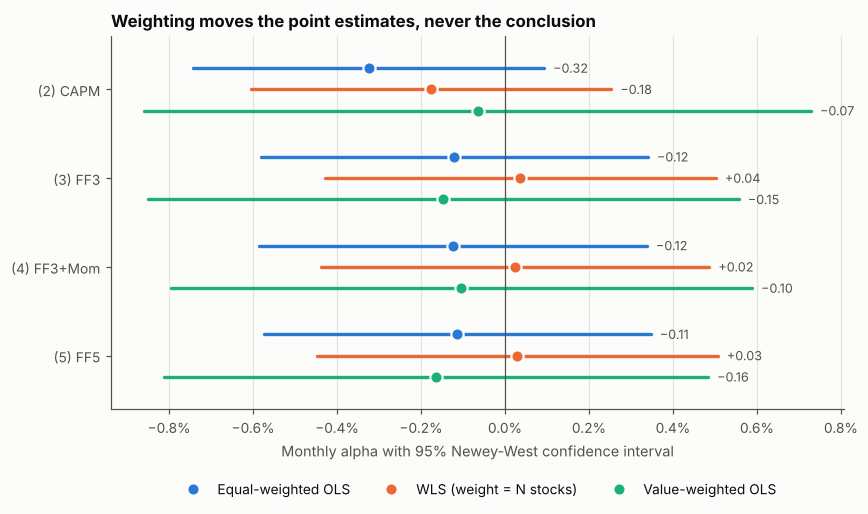


=== table8b_loadings ===


,Mkt-RF,SMB,HML,Mom
EW (3) FF3,1.003,0.505,-0.091,
EW (4) FF3+Mom,1.005,0.507,-0.088,0.009
WLS (3) FF3,0.981,0.465,-0.130,
WLS (4) FF3+Mom,0.988,0.471,-0.121,0.028
VW (3) FF3,1.260,-0.013,-0.749,
VW (4) FF3+Mom,1.227,-0.048,-0.791,-0.128


In [13]:
cap_prev = mon_stock.mktcap_end.copy()
held["mi_prev"] = held.mi - 1
held["cap_prev"] = [cap_prev.get((p, m), np.nan) for p, m in zip(held.permno, held.mi_prev)]
check("held stock-months lacking previous-month cap", int(held.cap_prev.isna().sum()))
held["w"] = held.cap_prev / held.groupby("mi").cap_prev.transform("sum")
check("VW weights sum to 1 in every month (max abs deviation)", f"{(held.groupby('mi').w.sum() - 1).abs().max():.2e}")
vw = held.groupby("mi").apply(lambda g: (g.w * g.ret_stock).sum(), include_groups=False).rename("rp_vw")
maxw = held.groupby("mi").w.max()
check("VW: average / max (over months) of largest single-stock weight", f"{maxw.mean():.3f} / {maxw.max():.3f}")
check("VW: average effective number of stocks (1/sum w^2)", f"{(1 / held.groupby('mi').w.apply(lambda s: (s ** 2).sum())).mean():.1f}")
panel_m["rp_vw"] = vw
panel_m["ex_vw"] = panel_m.rp_vw - panel_m.rf
check("corr(EW, VW) portfolio return", f"{panel_m.rp.corr(panel_m.rp_vw):.3f}")
check("mean monthly return EW vs VW (decimal)", f"{panel_m.rp.mean():.4f} vs {panel_m.rp_vw.mean():.4f}")

tab8_rows = {}
res8 = {}
for name, fac in MODELS.items():
    X = panel_m[fac] if fac else None
    o_ew, n_ew = fit(panel_m.ex, X)
    o_w, n_w = fit(panel_m.ex, X, w=panel_m.n)
    o_vw, n_vw = fit(panel_m.ex_vw, X)
    res8[name] = (o_ew, n_ew, o_w, n_w, o_vw, n_vw)
    tab8_rows[name] = {
        "EW OLS: alpha (%)": o_ew.params["const"] * 100, "EW OLS: t (NW)": n_ew.tvalues["const"], "EW OLS: t (OLS)": o_ew.tvalues["const"],
        "WLS (w = N): alpha (%)": o_w.params["const"] * 100, "WLS: t (NW)": n_w.tvalues["const"], "WLS: t (OLS)": o_w.tvalues["const"],
        "VW (prev. cap): alpha (%)": o_vw.params["const"] * 100, "VW: t (NW)": n_vw.tvalues["const"], "VW: t (OLS)": o_vw.tvalues["const"],
    }
tab8_full = pd.DataFrame(tab8_rows).T.round(3)
tab8_full.to_csv(OUT_DIR / "table8_weighting_full.csv")
tab8 = pd.DataFrame({
    "alpha (%)": [f"{res8[m][0].params['const'] * 100:.3f}{sig_stars(res8[m][1].tvalues['const'])}" for m in MODELS],
    "t (NW)": [f"[{res8[m][1].tvalues['const']:.2f}]" for m in MODELS],
    "alpha (%) ": [f"{res8[m][2].params['const'] * 100:.3f}{sig_stars(res8[m][3].tvalues['const'])}" for m in MODELS],
    "t (NW) ": [f"[{res8[m][3].tvalues['const']:.2f}]" for m in MODELS],
    "alpha (%)  ": [f"{res8[m][4].params['const'] * 100:.3f}{sig_stars(res8[m][5].tvalues['const'])}" for m in MODELS],
    "t (NW)  ": [f"[{res8[m][5].tvalues['const']:.2f}]" for m in MODELS],
}, index=list(MODELS))
save_table(tab8, "table8_weighting",
           "Q8: monthly alpha (percent) by weighting scheme. Equal-weighted: the Q6 portfolio, OLS across months. WLS: same portfolio, each month weighted by the number of stocks held. "
           "Value-weighted: stocks weighted by market cap at the end of the previous month, OLS across months.",
           "tab:q8", colfmt="lrrrrrr", groups=[("Equal-weighted, OLS", 2), ("Equal-weighted, WLS (w = N)", 2), ("Value-weighted, OLS", 2)],
           note=f"Stars: significance of the Newey-West $t$ ({NW_LAGS} lags, in brackets): * 10\\%, ** 5\\%, *** 1\\%. Usual OLS $t$-statistics are in table8\\_weighting\\_full.csv and give the same conclusions.")
# ---- Figure 6: alpha by weighting scheme (Q8) ----
fig, ax = plt.subplots(figsize=(8.6, 4.4))
schemes = [("Equal-weighted OLS", 0, 1, C["blue"], 0.24), ("WLS (weight = N stocks)", 2, 3, C["orange"], 0.0), ("Value-weighted OLS", 4, 5, C["aqua"], -0.24)]
mods = [m for m in MODELS if m != "(1) No factors"]
for lab_, io, inw, col, off in schemes:
    for k, m_ in enumerate(mods):
        y_ = len(mods) - 1 - k + off
        a_, se_ = res8[m_][io].params["const"] * 100, res8[m_][inw].bse["const"] * 100
        ax.plot([a_ - 1.96 * se_, a_ + 1.96 * se_], [y_, y_], color=col, linewidth=2.2, solid_capstyle="round")
        ax.plot(a_, y_, "o", color=col, markersize=8, markeredgecolor=C["surface"], markeredgewidth=1.4, label=lab_ if k == 0 else None)
        ax.annotate(f"{a_:+.2f}".replace("-", "\u2212"), (a_ + 1.96 * se_, y_), xytext=(6, 0), textcoords="offset points", va="center", fontsize=8.3, color=C["ink2"])
ax.axvline(0, color=C["ink2"], linewidth=0.8)
ax.set_yticks(range(len(mods))); ax.set_yticklabels(mods[::-1]); ax.set_ylim(-0.6, len(mods) - 0.4)
ax.xaxis.set_major_formatter(pct1); ax.set_xlabel("Monthly alpha with 95% Newey-West confidence interval")
ax.set_title("Weighting moves the point estimates, never the conclusion")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
finish_fig(fig, "fig6_weighting")
# loadings for VW and WLS, for discussion
loadings = {}
for tag, k in [("EW", 0), ("WLS", 2), ("VW", 4)]:
    for name in ["(3) FF3", "(4) FF3+Mom"]:
        o = res8[name][k]
        loadings[f"{tag} {name}"] = o.params.drop("const").round(3)
loadings = pd.DataFrame(loadings).T[["Mkt-RF", "SMB", "HML", "Mom"]].fillna("")
save_table(loadings.apply(lambda c: [f"{v:.3f}" if v != "" else "" for v in c]), "table8b_loadings", "Q8 (supporting): factor loadings under each weighting scheme. The value-weighted portfolio is a large-cap growth portfolio (beta 1.2--1.3, HML $\\approx -0.75$, SMB $\\approx 0$).", "tab:q8b", colfmt="lrrrr")

## Robustness: drop events touched by the fill rule or by the stop-trading rule; winsorise BHAR

In [14]:
fill_ev = set(ev.event_id[[((fills.permno == p) & (fills.mi > m0) & (fills.mi <= m0 + 12)).any() for p, m0 in zip(ev.permno, ev.m0)]])
excl = fill_ev | set(ev.event_id[ev.cut_stop])
rob_rows = {}
y = ev[ev.bhar_ok & ~ev.event_id.isin(excl)].bhar_mkt
rob_rows["BHAR vs. market, excluding fill/stop events"] = (len(y), y.mean() * 100, y.mean() / (y.std() / np.sqrt(len(y))))
lo, hi = x.quantile([0.01, 0.99])
xw = x.clip(lo, hi)
rob_rows["BHAR vs. market, winsorised at 1/99"] = (len(xw), xw.mean() * 100, xw.mean() / (xw.std() / np.sqrt(len(xw))))
h2 = pan[~pan.event_id.isin(excl) & pan.held][["permno", "mi", "ret_stock"]].drop_duplicates(["permno", "mi"])
m2 = h2.groupby("mi").ret_stock.mean().to_frame("rp")
m2["ex"] = m2.rp - ff3.RF.reindex(m2.index)
o2 = sm.OLS(m2.ex, sm.add_constant(ff3["Mkt-RF"].reindex(m2.index))).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
rob_rows["CAPM alpha (%/month), excluding fill/stop events"] = (len(m2), o2.params["const"] * 100, o2.tvalues["const"])
rob = pd.DataFrame(rob_rows, index=["N", "Estimate (%)", "t-statistic"]).T.round(2)
rob["N"] = rob.N.astype(int)
save_table(fmt_df(rob, 2), "table_robustness", "Robustness: dropping the events touched by the empty-day fill rule (2) or the stopped-trading rule (4), and winsorising BHARs at the 1st and 99th percentiles. "
           "Estimates are percent (BHAR) or percent per month (alpha); t-statistics are conventional for BHAR and Newey-West for alpha.", "tab:rob", colfmt="p{8cm}rrr")


=== table_robustness ===


,N,Estimate (%),t-statistic
"BHAR vs. market, excluding fill/stop events",208,0.78,0.32
"BHAR vs. market, winsorised at 1/99",213,0.46,0.20
"CAPM alpha (%/month), excluding fill/stop events",143,-0.32,-1.47


## Q6/Q7 supporting tables: alpha decomposition and BHAR <-> alpha bridge


=== table6c_alpha_decomposition ===


,(2) CAPM,(3) FF3,(4) FF3+Mom,(5) FF5
Mean excess return (%/month),0.796,0.796,0.796,0.796
Alpha,-0.325,-0.121,-0.124,-0.114
Mkt-RF: loading x mean factor,1.121,1.019,1.021,1.005
SMB: loading x mean factor,,-0.112,-0.112,-0.111
HML: loading x mean factor,,0.009,0.009,0.012
Mom: loading x mean factor,,,0.001,
RMW: loading x mean factor,,,,-0.013
CMA: loading x mean factor,,,,0.017
Sum (alpha + contributions),0.796,0.796,0.796,0.796


[CHECK] decomposition identity: max |sum - mean excess|: 1.4e-14  

=== table6d_factor_means ===


,Mean (%/month),Std. dev. (%/month)
Mkt-RF,1.017,4.349
SMB,-0.221,2.752
HML,-0.103,3.620
Mom,0.163,3.822
RMW_5,0.286,2.086
CMA_5,-0.110,2.287



=== table7_bridge ===


,Percent per year
(a) Mean 12-month BHAR vs. mkt_ret,0.74
(b) Mean 12-month BHAR vs. French market,-0.62
(c) Event-month mean of (R_i - mkt_ret) x 12,0.93
(d) Calendar-month mean of (R_p - mkt_ret) x 12,-1.35
(e) Calendar-month mean of (R_p - French market) x 12,-2.65
(f) CAPM alpha x 12,-3.89
(g) Three-factor alpha x 12,-1.45
(h) Four-factor (with Mom) alpha x 12,-1.49


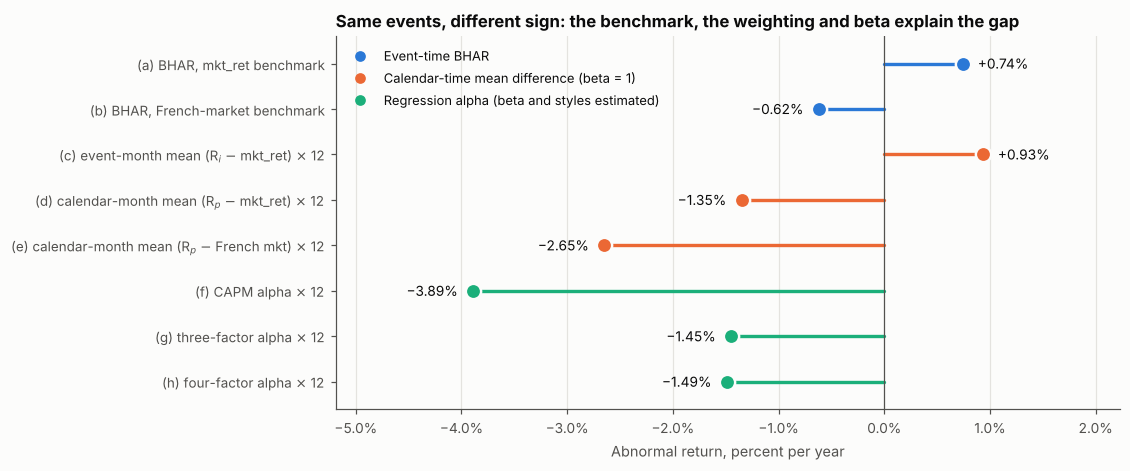

In [15]:
dec_rows = {}
for name in ["(2) CAPM", "(3) FF3", "(4) FF3+Mom", "(5) FF5"]:
    o = res6[name][0]
    r = {"Mean excess return (%/month)": panel_m.ex.mean() * 100, "Alpha": o.params["const"] * 100}
    for f in MODELS[name]:
        r[f"{LABEL.get(f, f)}: loading x mean factor"] = o.params[f] * panel_m[f].mean() * 100
    r["Sum (alpha + contributions)"] = o.params["const"] * 100 + sum(o.params[f] * panel_m[f].mean() * 100 for f in MODELS[name])
    dec_rows[name] = r
row_order = ["Mean excess return (%/month)", "Alpha"] + [f"{f}: loading x mean factor" for f in ["Mkt-RF", "SMB", "HML", "Mom", "RMW", "CMA"]] \
    + ["Sum (alpha + contributions)"]
dec_tab = pd.DataFrame(dec_rows).reindex([r for r in row_order if r in set().union(*[set(v) for v in dec_rows.values()])]).round(3).fillna("")
save_table(dec_tab, "table6c_alpha_decomposition",
           "Q6 (supporting): decomposition of the portfolio's mean monthly excess return (percent per month) into alpha and (loading $\\times$ sample-mean factor). "
           "The last row equals the first row (identity check). Moving from CAPM to three factors raises alpha by 0.20 pp: 0.10 pp from a lower market beta and 0.11 pp from the SMB loading times the negative SMB premium.", "tab:q6c", colfmt="lrrrr", bold_rows=("Alpha",), shade_rows=("Alpha",), rule_before=("Sum (alpha + contributions)",), space_before=("Mkt-RF: loading x mean factor",))
check("decomposition identity: max |sum - mean excess|", f"{max(abs(float(v['Sum (alpha + contributions)']) - float(v['Mean excess return (%/month)'])) for v in dec_rows.values()):.1e}")
fm = pd.DataFrame({"Mean (%/month)": panel_m[["Mkt-RF", "SMB", "HML", "Mom", "RMW_5", "CMA_5"]].mean() * 100,
                   "Std. dev. (%/month)": panel_m[["Mkt-RF", "SMB", "HML", "Mom", "RMW_5", "CMA_5"]].std() * 100}).round(3)
save_table(fmt_df(fm, 3), "table6d_factor_means", "Q6 (supporting): mean and standard deviation of the factors over the portfolio's months (percent per month).", "tab:q6d", colfmt="lrr")

fullb = pan[pan.event_id.isin(ev[ev.bhar_ok].event_id)]
mkt_cal = panel_m.index.map(mon_mkt)
fr_cal = (ff3["Mkt-RF"] + ff3["RF"]).reindex(panel_m.index)
bridge = pd.Series({
    "(a) Mean 12-month BHAR vs. mkt_ret": st_mkt["Mean"] * 100,
    "(b) Mean 12-month BHAR vs. French market": st_fr["Mean"] * 100,
    "(c) Event-month mean of (R_i - mkt_ret) x 12": (fullb.ret_used - fullb.ret_mkt).mean() * 12 * 100,
    "(d) Calendar-month mean of (R_p - mkt_ret) x 12": (panel_m.rp - mkt_cal).mean() * 12 * 100,
    "(e) Calendar-month mean of (R_p - French market) x 12": (panel_m.rp - fr_cal).mean() * 12 * 100,
    "(f) CAPM alpha x 12": res6["(2) CAPM"][0].params["const"] * 12 * 100,
    "(g) Three-factor alpha x 12": res6["(3) FF3"][0].params["const"] * 12 * 100,
    "(h) Four-factor (with Mom) alpha x 12": res6["(4) FF3+Mom"][0].params["const"] * 12 * 100,
}).round(2).to_frame("Percent per year")
bridge_raw = bridge.copy()
bridge = bridge.map(lambda v: f"{v:.2f}")
save_table(bridge, "table7_bridge",
           "Q7 (bridge): from the 12-month BHAR to the calendar-time alphas, in percent per year. (a)-(b) change only the benchmark; "
           "(c)-(d) change from event weighting to calendar-month weighting and from compounded to arithmetic returns; (f)-(h) let the model "
           "adjust for market beta and style loadings. Alphas are monthly alphas multiplied by 12. French market = Mkt-RF + RF.", "tab:q7", colfmt="p{9cm}r", space_before=("(c) Event-month mean of (R_i - mkt_ret) x 12", "(f) CAPM alpha x 12"),
           bold_rows=("(a) Mean 12-month BHAR vs. mkt_ret", "(f) CAPM alpha x 12"), shade_rows=("(a) Mean 12-month BHAR vs. mkt_ret", "(f) CAPM alpha x 12"))

# ---- Figure 5: bridge from BHAR to alpha (Q7) ----
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols_ = [C["blue"]] * 2 + [C["orange"]] * 3 + [C["aqua"]] * 3
short = ["(a) BHAR, mkt_ret benchmark", "(b) BHAR, French-market benchmark", "(c) event-month mean (R$_i$ $-$ mkt_ret) $\\times$ 12",
         "(d) calendar-month mean (R$_p$ $-$ mkt_ret) $\\times$ 12", "(e) calendar-month mean (R$_p$ $-$ French mkt) $\\times$ 12",
         "(f) CAPM alpha $\\times$ 12", "(g) three-factor alpha $\\times$ 12", "(h) four-factor alpha $\\times$ 12"]
vals = bridge_raw.iloc[:, 0].values
for k, (v_, c_) in enumerate(zip(vals, cols_)):
    y_ = len(vals) - 1 - k
    ax.plot([0, v_], [y_, y_], color=c_, linewidth=2.2, solid_capstyle="round")
    ax.plot(v_, y_, "o", color=c_, markersize=10, markeredgecolor=C["surface"], markeredgewidth=1.6)
    ax.annotate(f"{v_:+.2f}%".replace("-", "\u2212"), (v_, y_), xytext=(10 if v_ >= 0 else -10, 0), textcoords="offset points", va="center", ha="left" if v_ >= 0 else "right", fontsize=9)
ax.axvline(0, color=C["ink2"], linewidth=0.8)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(short[::-1], fontsize=8.8); ax.set_ylim(-0.6, len(vals) - 0.4); ax.set_xlim(vals.min() - 1.3, vals.max() + 1.3)
ax.xaxis.set_major_formatter(pct1); ax.set_xlabel("Abnormal return, percent per year")
ax.set_title("Same events, different sign: the benchmark, the weighting and beta explain the gap")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
for lab_, c_ in [("Event-time BHAR", C["blue"]), ("Calendar-time mean difference (beta = 1)", C["orange"]), ("Regression alpha (beta and styles estimated)", C["aqua"])]:
    ax.plot([], [], "o", color=c_, label=lab_)
ax.legend(loc="upper left", fontsize=8.5)
finish_fig(fig, "fig5_bridge")

## Save checks and key numbers

In [16]:
chk = pd.DataFrame(CHECKS).astype(str)
chk.to_csv(OUT_DIR / "sanity_checks.csv", index=False)
keep = ["daily rows", "split events", "daily duplicates (permno,date)", "daily missing ret / mkt_ret / mktcap", "ex-date range",
        "trading days in calendar", "explicit NaN ret in raw file", "empty stock-days inside stock history filled with mkt_ret",
        "stock-days in wholly-empty months (not filled, month treated as 'stopped trading')", "events whose window contains a day filled with mkt_ret",
        "events with trading obs in month 0", "expected panel rows = sum(min(12, DATA_END - m0))",
        "BHAR from panel vs direct daily compounding (8 random events), max abs diff",
        "monthly stock return inside event windows: min / max",
        "corr(compounded mkt_ret, French Mkt-RF+RF) monthly", "mean monthly diff (mkt_ret - French Mkt), and 2014-2025 compounded return of each",
        "events with size decile assigned", "cap at month 0: median / min / max ($ millions)",
        "held event-months before / after removing overlapping splits of the same stock", "EW weights sum to 1 in every month (max abs deviation)",
        "VW weights sum to 1 in every month (max abs deviation)", "VW: average / max (over months) of largest single-stock weight",
        "VW: average effective number of stocks (1/sum w^2)", "model (1) alpha == mean excess return",
        "CAPM alpha/beta: statsmodels vs numpy lstsq (max abs diff)", "decomposition identity: max |sum - mean excess|",
        "SE of mean BHAR: iid vs clustered by ex-date month", "robustness: mean BHAR vs French market / t"]
chk_tab = chk[chk.check.isin(keep)][["check", "value"]].set_index("check")
chk_tab.index.name = None
chk_tab.columns = ["Result"]
save_table(chk_tab, "table_checks", "Appendix: data and results checks (selected). Full list in sanity\\_checks.csv.", "tab:checks", colfmt="p{9cm}p{6cm}")
ev.drop(columns=["m0_has_obs"]).to_csv(OUT_DIR / "events_with_bhar.csv", index=False)
panel_m.to_csv(OUT_DIR / "calendar_portfolio.csv")
json.dump({"bhar_mkt": {k: float(v) for k, v in st_mkt.items()},
           "bhar_dec": {k: float(v) for k, v in st_dec.items()},
           "bhar_diff": {k: float(v) for k, v in st_diff.items()},
           "cluster_se_mkt": float(se_cl)},
          open(OUT_DIR / "key_numbers.json", "w"), indent=1)
print("\nDone. Outputs in", OUT_DIR)


=== table_checks ===


,Result
daily rows,629274
split events,232
"daily duplicates (permno,date)",0
daily missing ret / mkt_ret / mktcap,0 / 0 / 0
ex-date range,2014-01-08 to 2025-12-23
trading days in calendar,3520
explicit NaN ret in raw file,0
empty stock-days inside stock history filled with mkt_ret,91
"stock-days in wholly-empty months (not filled, month treated as 'stopped trading')",923
"corr(compounded mkt_ret, French Mkt-RF+RF) monthly",0.99772



Done. Outputs in /home/user/farmdat/ps1b/output
